In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


lat_col = "network_latency"
bw_col = "network_bandwidth"
time_col = "time"
alg_col = "algorithm"
len_col = "prompt_length"

# df_voltage = pd.read_json("../results/orin_voltage_4.json") 
# df_voltage = pd.read_json("../results/voltage_orin_sim_4.json") 
df_voltage = pd.read_json("../results/quest/voltage_cpu_2.json") 
df_voltage[alg_col] = "voltage"

# df_voltage_improv = pd.read_json("../results/orin_voltage_improv_4.json") 
# df_voltage_improv = pd.read_json("../results/voltage_improv_orin_sim_4.json")
df_voltage_improv = pd.read_json("../results/quest/voltage_improv_cpu_2.json") 
df_voltage_improv[alg_col] = "voltage_improv"

df = pd.concat([df_voltage, df_voltage_improv], ignore_index=True)

df[bw_col] = df[bw_col].apply(lambda x: x * 1e-6)  # convert to Mbps
df[lat_col] = df[lat_col].apply(lambda x: x * 1e3)  # convert to ms

# Clean data that has warmup effects
# Find the mean std for each lat_col, bw_col and exclude all entries that are outside 2 stds
def clean_warmup_effects(df):
    clean_dfs = []
    for (lat, bw, alg, length), group in df.groupby([lat_col, bw_col, alg_col, len_col]):
        time_mean = group[time_col].mean()
        time_std = group[time_col].std()
        print(f"For lat: {lat}, bw: {bw}, alg: {alg}, length: {length} => mean: {time_mean}, std: {time_std}")
        clean_group = group[(group[time_col] >= time_mean - 2 * time_std) & (group[time_col] <= time_mean + 2 * time_std)]
        clean_dfs.append(clean_group)
    return pd.concat(clean_dfs, ignore_index=True)

df = clean_warmup_effects(df)

df

For lat: 1.0, bw: 10.0, alg: voltage, length: 269 => mean: 1.9249345974138898, std: 0.23766281355115598
For lat: 1.0, bw: 10.0, alg: voltage, length: 490 => mean: 3.013667386044159, std: 0.012595857952123738
For lat: 1.0, bw: 10.0, alg: voltage, length: 1002 => mean: 5.496043780767651, std: 0.020001846871667422
For lat: 1.0, bw: 10.0, alg: voltage, length: 2026 => mean: 10.630372635760782, std: 0.01938937291096556
For lat: 1.0, bw: 10.0, alg: voltage_improv, length: 269 => mean: 1.8510283039261757, std: 0.1994034506472744
For lat: 1.0, bw: 10.0, alg: voltage_improv, length: 490 => mean: 2.919136592904448, std: 0.01313823275189173
For lat: 1.0, bw: 10.0, alg: voltage_improv, length: 1002 => mean: 5.356395263359387, std: 0.019697656585373386
For lat: 1.0, bw: 10.0, alg: voltage_improv, length: 2026 => mean: 10.362419518499536, std: 0.016296366265403622
For lat: 1.0, bw: 100.0, alg: voltage, length: 269 => mean: 1.3499800956347314, std: 0.004537404732403429
For lat: 1.0, bw: 100.0, alg: v

,timestamp,time,device_count,max_seq_len,prompt_length,max_tokens,network_bandwidth,network_latency,total_transmit_duration,total_transmit_size,transmit_count,yield_count,log_file,algorithm
0,2025-10-21 19:36:06.751020193,2.178986,2,64,269,1,10.0,1.0,1.077263,10354688.25,34,70,profile_out/event_log_1761075366.7453542.jsonl,voltage
1,2025-10-21 19:36:09.347060442,1.818006,2,64,269,1,10.0,1.0,1.069469,10354688.25,34,70,profile_out/event_log_1761075369.343343.jsonl,voltage
2,2025-10-21 19:36:11.944726706,1.819766,2,64,269,1,10.0,1.0,1.069469,10354688.25,34,70,profile_out/event_log_1761075371.941065.jsonl,voltage
3,2025-10-21 19:36:14.537878036,1.817433,2,64,269,1,10.0,1.0,1.069469,10354688.25,34,70,profile_out/event_log_1761075374.5340781.jsonl,voltage
4,2025-10-21 19:36:17.132698536,1.820941,2,64,269,1,10.0,1.0,1.069469,10354688.25,34,70,profile_out/event_log_1761075377.1289527.jsonl,voltage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517,2025-10-21 20:21:58.506279469,3.908068,2,256,1002,1,1000.0,20.0,0.715521,35520512.25,34,70,profile_out/event_log_1761078118.5018923.jsonl,voltage_improv
518,2025-10-21 20:22:05.908335924,3.892052,2,256,1002,1,1000.0,20.0,0.715521,35520512.25,34,70,profile_out/event_log_1761078125.9040182.jsonl,voltage_improv
519,2025-10-21 20:22:13.334607840,3.903881,2,256,1002,1,1000.0,20.0,0.715521,35520512.25,34,70,profile_out/event_log_1761078133.329324.jsonl,voltage_improv
520,2025-10-21 20:22:20.781673431,3.922569,2,256,1002,1,1000.0,20.0,0.715521,35520512.25,34,70,profile_out/event_log_1761078140.7771916.jsonl,voltage_improv


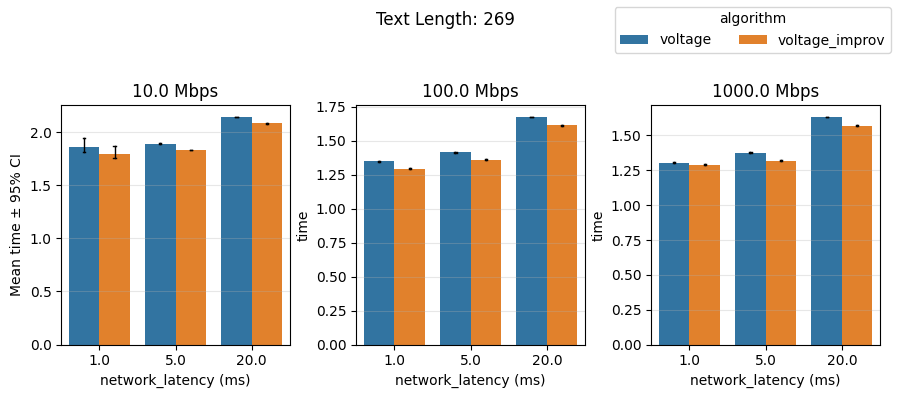

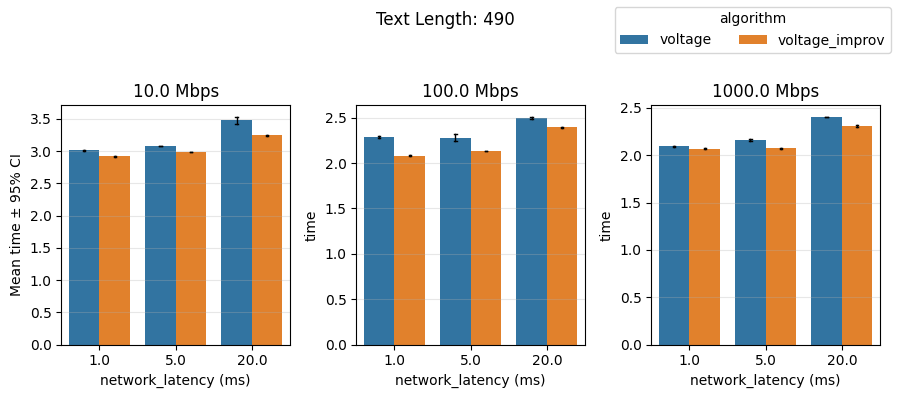

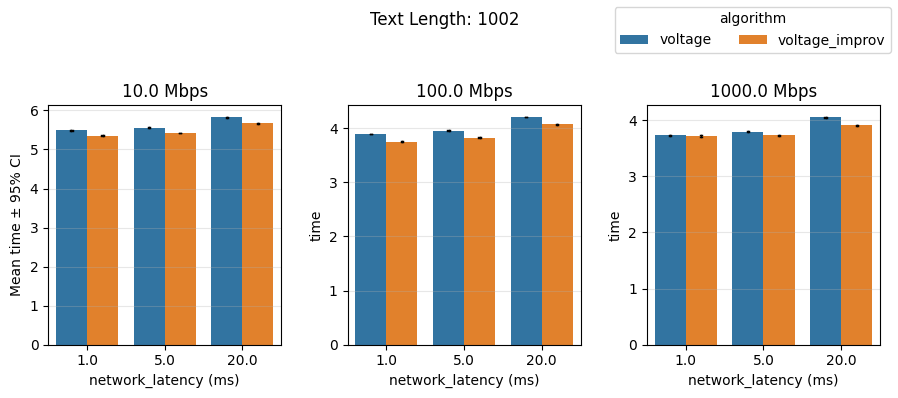

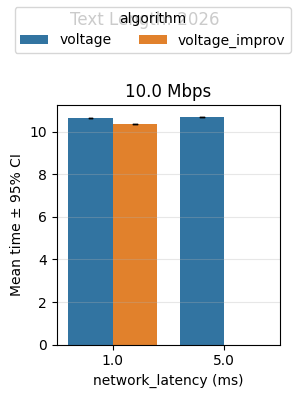

In [2]:
import seaborn as sns

# Use seaborn barplot so we get mean + confidence intervals (default ci=95)
for text_len in df[len_col].unique():
    df_len = df[df[len_col] == text_len]

    # Helpers for ordering
    def _to_num(x):
        try:
            return float(str(x).strip().lower().replace("ms", "").replace("s", ""))
        except:
            return x

    lat_order = sorted(df_len[lat_col].unique(), key=_to_num)
    alg_order = list(df_len[alg_col].dropna().unique())
    bw_vals = sorted(df_len[bw_col].unique(), key=_to_num)

    # determine y-limit from raw data (safer for CI visualization)
    ymax = df_len[time_col].max() * 1.10

    fig, axes = plt.subplots(1, len(bw_vals), figsize=(3 * len(bw_vals), 4), sharey=False)
    if len(bw_vals) == 1:
        axes = [axes]

    for ax, bw in zip(axes, bw_vals):
        sub = df_len[df_len[bw_col] == bw]

        sns.barplot(
            data=sub,
            x=lat_col,
            y=time_col,
            hue=alg_col,
            order=lat_order,
            hue_order=alg_order,
            ax=ax,
            errorbar=('ci', 95),
            capsize=0.06,
            palette="tab10",
            err_kws={'color': 'k', 'linewidth': 1},
        )

        ax.set_title(f"{bw} Mbps")
        ax.set_xlabel(lat_col + " (ms)")
        # ax.set_ylim(0, ymax)
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="x", rotation=0)

    axes[0].set_ylabel(f"Mean {time_col} ± 95% CI")
    fig.suptitle(f"Text Length: {text_len}", fontsize=12)
    # single legend for the figure
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, title=alg_col, loc="upper right", ncol=len(alg_order))
    # remove per-axis legends
    for a in axes:
        a.legend_.remove()
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    # Save as pdf
    plt.savefig(f"../results/voltage_analysis_text_length_{text_len}.pdf")
    plt.show()


In [3]:
from scipy.stats import ttest_ind

results = []

for text_len in df[len_col].unique():
    df_len = df[df[len_col] == text_len]
    for bw in df_len[bw_col].unique():
        for lat in df_len[lat_col].unique():
            sub = df_len[(df_len[lat_col] == lat) & (df_len[bw_col] == bw)]
            vals0 = sub[sub[alg_col] == alg_order[0]][time_col]
            vals1 = sub[sub[alg_col] == alg_order[1]][time_col]
            if len(vals0) > 1 and len(vals1) > 1:
                t_stat, p_val = ttest_ind(vals0, vals1, equal_var=False)
            else:
                p_val = float('nan')
            mean0 = vals0.mean()
            mean1 = vals1.mean()
            if not pd.isna(mean0) and not pd.isna(mean1):
                speedup = mean0 / mean1 if mean1 != 0 else float('nan')
                results.append({
                    len_col: int(text_len),
                    bw_col: int(bw),
                    lat_col: int(lat),
                    f"{alg_order[0]}_mean_time": f"{mean0:.3f}",
                    f"{alg_order[1]}_mean_time": f"{mean1:.3f}",
                    "speedup": f"{(speedup-1)*100:.2f}%",
                    "p_value": f"{p_val:.3f}"
                })

speedup_df = pd.DataFrame(results)
# Export as csv
speedup_df.to_csv("../results/voltage_speedup_analysis.csv", index=False)
display(speedup_df)

,prompt_length,network_bandwidth,network_latency,voltage_mean_time,voltage_improv_mean_time,speedup,p_value
0,269,10,1,1.859,1.796,3.48%,0.258
1,269,10,5,1.892,1.830,3.38%,0.000
2,269,10,20,2.144,2.083,2.93%,0.000
3,269,100,1,1.350,1.296,4.19%,0.000
4,269,100,5,1.415,1.361,3.96%,0.000
5,269,100,20,1.675,1.615,3.71%,0.000
6,269,1000,1,1.305,1.290,1.18%,0.000
7,269,1000,5,1.376,1.318,4.42%,0.000
8,269,1000,20,1.632,1.569,4.03%,0.000
9,490,10,1,3.010,2.915,3.24%,0.000
